In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
# Cell 2 — Load data and retrain model
train = pd.read_csv("../data/spy_train.csv", index_col=0, parse_dates=True)
test = pd.read_csv("../data/spy_test.csv", index_col=0, parse_dates=True)

features = ['Close_Lag_1', 'Close_Lag_5', 'Close_Lag_20',
            'Daily_Return', 'Volatility_30', 'MA_20', 'MA_50']
target = 'Target'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                   max_depth=4, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
baseline_pred = np.zeros(len(y_test))

print("Model retrained successfully")

Model retrained successfully


In [3]:
# Cell 3 — Directional accuracy
actual_direction = np.sign(y_test)
xgb_direction = np.sign(xgb_pred)
baseline_direction = np.sign(baseline_pred)

xgb_directional_acc = np.mean(actual_direction == xgb_direction) * 100
baseline_directional_acc = np.mean(actual_direction == baseline_direction) * 100

print("=== Directional Accuracy ===")
print(f"Baseline:  {baseline_directional_acc:.2f}%")
print(f"XGBoost:   {xgb_directional_acc:.2f}%")

=== Directional Accuracy ===
Baseline:  0.00%
XGBoost:   42.36%


In [4]:
# Cell 4 — Full metrics summary
mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("=== Full Model Evaluation ===")
print(f"{'Metric':<25} {'Baseline':>12} {'XGBoost':>12}")
print(f"{'MAE':<25} {mae_base:>12.4f} {mae_xgb:>12.4f}")
print(f"{'RMSE':<25} {rmse_base:>12.4f} {rmse_xgb:>12.4f}")
print(f"{'Directional Accuracy':<25} {baseline_directional_acc:>11.2f}% {xgb_directional_acc:>11.2f}%")

=== Full Model Evaluation ===
Metric                        Baseline      XGBoost
MAE                             0.0066       0.0169
RMSE                            0.0101       0.0194
Directional Accuracy             0.00%       42.36%


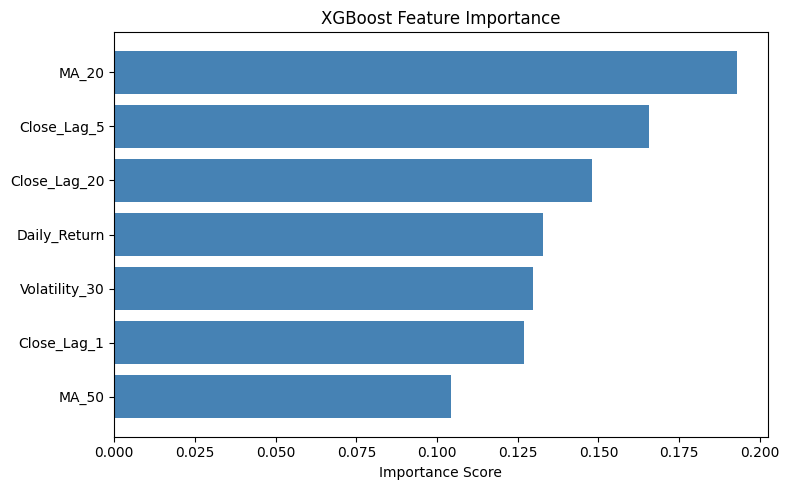

In [5]:
# Cell 5 — Feature importance
importances = xgb.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

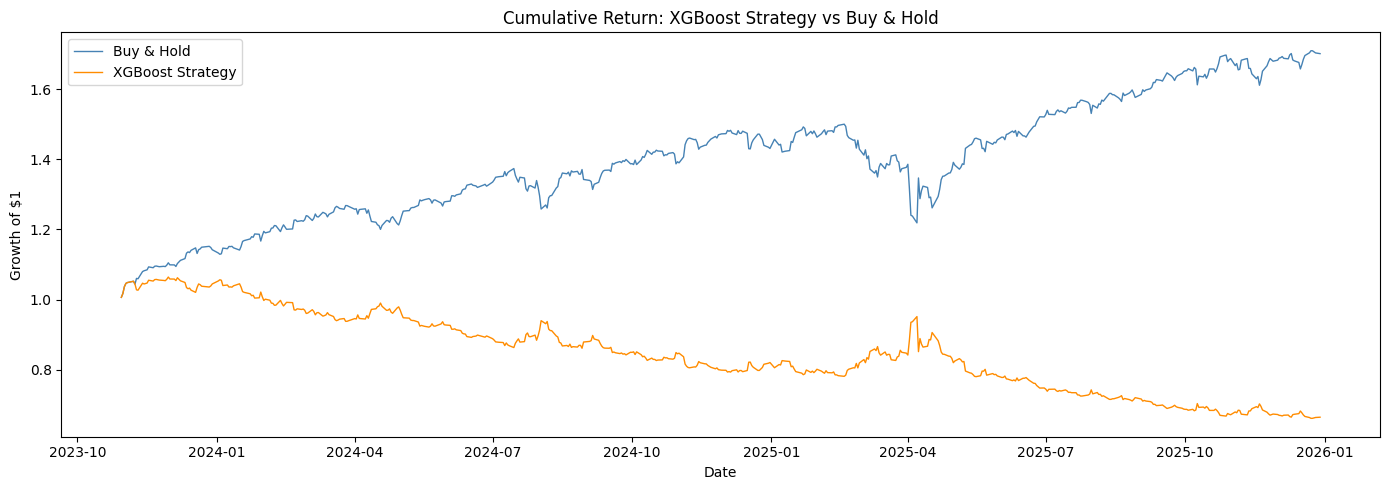

In [6]:
# Cell 6 — Cumulative return simulation
test_eval = test.copy()
test_eval['XGB_Pred'] = xgb_pred
test_eval['Signal'] = np.where(test_eval['XGB_Pred'] > 0, 1, -1)
test_eval['Strategy_Return'] = test_eval['Signal'] * test_eval['Target']
test_eval['Cumulative_Strategy'] = (1 + test_eval['Strategy_Return']).cumprod()
test_eval['Cumulative_BuyHold'] = (1 + test_eval['Target']).cumprod()

plt.figure(figsize=(14, 5))
plt.plot(test_eval.index, test_eval['Cumulative_BuyHold'], 
         label='Buy & Hold', color='steelblue', linewidth=1)
plt.plot(test_eval.index, test_eval['Cumulative_Strategy'], 
         label='XGBoost Strategy', color='darkorange', linewidth=1)
plt.title('Cumulative Return: XGBoost Strategy vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
plt.show()